# 02. Boosting 모델 학습

학습 기간 유연 설정 (PERIOD_MODE 사용)

In [893]:
import pandas as pd, numpy as np, warnings
import xgboost as xgb, lightgbm as lgb, optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostRegressor,CatBoostClassifier
from imblearn.over_sampling import SMOTE
import sklearn.preprocessing
import pickle

smote = SMOTE(random_state=42)
warnings.filterwarnings("ignore")
# ════════════════════════════════════════════════
# ✏️  학습 기간 설정 (세 가지 방식 중 하나만 선택)
# ════════════════════════════════════════════════

PERIOD_MODE = "from"       # "range"   : 특정 구간만 학습
                            # "exclude" : 특정 구간을 제외하고 학습
                            # "from"    : 특정 연도 이후만 학습 (기존 방식)

PERIOD_START = 2020         # 구간 시작 연도 (range / exclude 공통)
PERIOD_END   = 2021       # 구간 종료 연도 (range / exclude 공통)
MIN_YEAR     = 2016         # "from" 모드일 때만 사용
# ════════════════════════════════════════════════

# 설정
FEATURE_VERSION = "v3"
SPLIT_STRATEGY = "year"
TARGET_TYPE = "regression" # regression , classification
TEST_SIZE = 0.2
RANDOM_STATE = 42
ENABLE_TUNING = True
N_TRIALS = 50
CV_FOLDS = 5
print(f"✅ 설정 완료: {FEATURE_VERSION}, PERIOD_MODE = {PERIOD_MODE}, PERIOD_START = {PERIOD_START}, PERIOD_END = {PERIOD_END} ,MIN_YEAR = {MIN_YEAR}")

✅ 설정 완료: v3, PERIOD_MODE = from, PERIOD_START = 2020, PERIOD_END = 2021 ,MIN_YEAR = 2016


In [894]:
# 데이터 로드
df = pd.read_csv(f"data/processed/feature_table_{FEATURE_VERSION}.csv", encoding="utf-8-sig")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3869 entries, 0 to 3868
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   movie_id                 3869 non-null   str    
 1   title                    3869 non-null   str    
 2   runtime                  3869 non-null   float64
 3   rating_encoded           3869 non-null   float64
 4   is_korean                3869 non-null   float64
 5   genre                    3869 non-null   str    
 6   open_date                3869 non-null   str    
 7   open_month               3869 non-null   float64
 8   open_day_of_week         3869 non-null   float64
 9   is_summer                3869 non-null   int64  
 10  is_winter                3869 non-null   int64  
 11  is_holiday_release       3869 non-null   int64  
 12  holiday_nearby_count     3869 non-null   int64  
 13  director_avg_audi        3869 non-null   float64
 14  director_movie_count     3869 non-n

In [895]:
# 데이터 로드
df = pd.read_csv(f"data/processed/feature_table_{FEATURE_VERSION}.csv", encoding="utf-8-sig")

# open_date를 datetime으로 변환 (결측치 처리)
df["open_date"] = pd.to_datetime(df["open_date"], errors="coerce")

# open_year 추출
df["open_year"] = df["open_date"].dt.year.astype("Int64")  # NaT 허용하는 정수형

# 코로나 기간 제외
df = (
    df[~df['open_year'].isin([2020, 2021])]
    .reset_index(drop=True)
)

# 검증
print(f"✅ {FEATURE_VERSION} 로드: {df.shape[0]:,}편")
print(f"   개봉 년도: {int(df['open_year'].min())}~{int(df['open_year'].max())}")
print(f"   open_date 결측치: {df['open_date'].isna().sum()}건")

✅ v3 로드: 3,348편
   개봉 년도: 1973~2025
   open_date 결측치: 0건


In [896]:
# PERIOD_MODE에 따라 학습 데이터 필터링

if PERIOD_MODE == "range":
    # 특정 구간만 학습 (예: 2012~2020)
    mask = (df["open_year"] >= PERIOD_START) & (df["open_year"] <= PERIOD_END)
    desc = f"{PERIOD_START}~{PERIOD_END}년"

elif PERIOD_MODE == "exclude":
    # 특정 구간 제외 (예: 코로나 2020~2021 제외)
    mask = ~((df["open_year"] >= PERIOD_START) & (df["open_year"] <= PERIOD_END))
    desc = f"{PERIOD_START}~{PERIOD_END}년 제외"

elif PERIOD_MODE == "from":
    # 특정 연도 이후만 (기존 방식)
    mask = df["open_year"] >= MIN_YEAR
    desc = f"{MIN_YEAR}년 이후"


df_train = df[mask].copy()

print(f"📅 학습 기간 모드  : {PERIOD_MODE} ({desc})")
print(f"   전체 데이터     : {len(df):,}편")
print(f"   학습 데이터     : {len(df_train):,}편")
print(f"   제외 데이터     : {len(df) - len(df_train):,}편")
print(f"   개봉 년도 범위  : {int(df_train['open_year'].min())}~{int(df_train['open_year'].max())}")

📅 학습 기간 모드  : from (2016년 이후)
   전체 데이터     : 3,348편
   학습 데이터     : 1,933편
   제외 데이터     : 1,415편
   개봉 년도 범위  : 2016~2025


In [897]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   movie_id                 3348 non-null   str           
 1   title                    3348 non-null   str           
 2   runtime                  3348 non-null   float64       
 3   rating_encoded           3348 non-null   float64       
 4   is_korean                3348 non-null   float64       
 5   genre                    3348 non-null   str           
 6   open_date                3348 non-null   datetime64[us]
 7   open_month               3348 non-null   float64       
 8   open_day_of_week         3348 non-null   float64       
 9   is_summer                3348 non-null   int64         
 10  is_winter                3348 non-null   int64         
 11  is_holiday_release       3348 non-null   int64         
 12  holiday_nearby_count     3348 non-null   int6

In [898]:
# 피처 준비
target_col = "log_audience" if TARGET_TYPE == "regression" else "hit_class"
y = df_train[target_col].copy()
exclude_cols = ["movie_id", "title", "total_audience", "log_audience", "hit_class", "open_date", "open_year"]
feature_cols = [c for c in df_train.columns if c not in exclude_cols]
X = df_train[feature_cols].copy()

# 범주형 인코딩
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
print(f"피처: {len(feature_cols)}, 샘플: {len(y):,}")

피처: 32, 샘플: 1,933


In [899]:
# Train/Test 분할
if SPLIT_STRATEGY == "year":
    sorted_idx = df_train.sort_values("open_year").index
    split_idx = int(len(sorted_idx) * (1 - TEST_SIZE))
    train_idx, test_idx = sorted_idx[:split_idx], sorted_idx[split_idx:]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

Train: 1,546, Test: 387


In [900]:
# smote 적용
smote = SMOTE(random_state=42)

In [901]:
# XGBoost
if TARGET_TYPE == "regression":
    xgb_model = xgb.XGBRegressor(max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbosity=0,class_weight='balanced')
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ XGBoost: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    xgb_model = xgb.XGBClassifier(objective="multi:softmax", num_class=4, max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbosity=0,class_weight='balanced')
    xgb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = xgb_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ XGBoost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(classification_report(y_test, y_pred))

✅ XGBoost: RMSE=0.9585, R²=0.7851


In [902]:
# LightGBM
if TARGET_TYPE == "regression":
    lgb_model = lgb.LGBMRegressor(max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    lgb_model.fit(X_train, y_train)
    y_pred = lgb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ LightGBM: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    lgb_model = lgb.LGBMClassifier(objective="multiclass", num_class=4, max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    lgb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = lgb_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ LightGBM: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(classification_report(y_test, y_pred))

✅ LightGBM: RMSE=0.9603, R²=0.7843


In [903]:
# Catboost
if TARGET_TYPE == "regression":
    cb_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    verbose=100
)
    cb_model.fit(X_train, y_train)
    y_pred = cb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ Catboost: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    cb_model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='R2',
    depth=6,
    learning_rate=0.03,
    iterations=2000,
    l2_leaf_reg=5,
    random_state=42,
    verbose=100
    )
    cb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = lgb_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Catboost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(classification_report(y_test, y_pred))

0:	learn: 0.0321278	total: 3.28ms	remaining: 6.56s
100:	learn: 0.8100907	total: 268ms	remaining: 5.05s
200:	learn: 0.8621782	total: 539ms	remaining: 4.83s
300:	learn: 0.8889544	total: 785ms	remaining: 4.43s
400:	learn: 0.9095167	total: 1.03s	remaining: 4.13s
500:	learn: 0.9247574	total: 1.27s	remaining: 3.81s
600:	learn: 0.9362624	total: 1.53s	remaining: 3.56s
700:	learn: 0.9464426	total: 1.85s	remaining: 3.43s
800:	learn: 0.9544583	total: 2.15s	remaining: 3.22s
900:	learn: 0.9615688	total: 2.5s	remaining: 3.05s
1000:	learn: 0.9675986	total: 2.79s	remaining: 2.79s
1100:	learn: 0.9722447	total: 3.1s	remaining: 2.53s
1200:	learn: 0.9760985	total: 3.37s	remaining: 2.24s
1300:	learn: 0.9793663	total: 3.63s	remaining: 1.95s
1400:	learn: 0.9820259	total: 3.94s	remaining: 1.69s
1500:	learn: 0.9843354	total: 4.2s	remaining: 1.4s
1600:	learn: 0.9862968	total: 4.46s	remaining: 1.11s
1700:	learn: 0.9878032	total: 4.74s	remaining: 833ms
1800:	learn: 0.9893502	total: 4.99s	remaining: 551ms
1900:	le

# Feature Correlation / Importance 분석 셀

## 1. log_audience와 상관계수 높은 feature 출력

In [904]:
# Boosting 학습 파일에 추가할 Feature Correlation / Importance 분석 셀
import matplotlib.pyplot as plt
import seaborn as sns

# 분석 대상 컬럼
exclude_cols = [
    'movie_id',
    'title',
    'genre',
    'open_date',
    'total_audience',
    'hit_class'
]

numeric_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

# 상관계수 계산
corr_series = (
    df[numeric_cols]
    .corr()['log_audience']
    .drop('log_audience')
    .sort_values(key=abs, ascending=False)
)

print('=' * 60)
print('log_audience 와의 상관계수 TOP 15')
print('=' * 60)
print(corr_series.head(15))

log_audience 와의 상관계수 TOP 15
lead_actor_avg_audi      0.386007
weekend_ratio            0.363751
cast_max_star_power      0.358165
runtime                  0.305610
director_avg_audi        0.301670
producer_avg_audi        0.280478
distributor_avg_audi     0.274183
relative_search_share    0.229640
trend_pre7_max           0.225637
trend_pre7_avg           0.223193
weekday_3_ratio         -0.214322
same_week_releases      -0.195830
weekday_2_ratio         -0.173554
open_year               -0.159772
is_korean                0.158577
Name: log_audience, dtype: float64


## 2. 상관계수 시각화

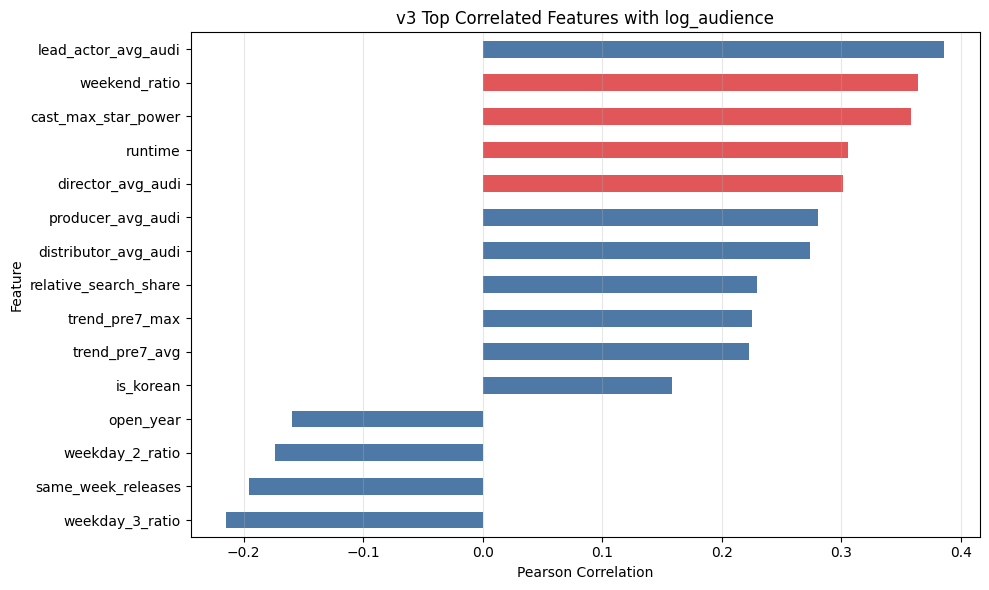

In [905]:
plt.figure(figsize=(10, 6))

colors = [
    '#4e79a7' if v > 0 else '#e15759'
    for v in corr_series.head(15).values
]

corr_series.head(15).sort_values().plot(
    kind='barh',
    color=colors
)

plt.title(f'{FEATURE_VERSION} Top Correlated Features with log_audience')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 전체 Feature Heatmap

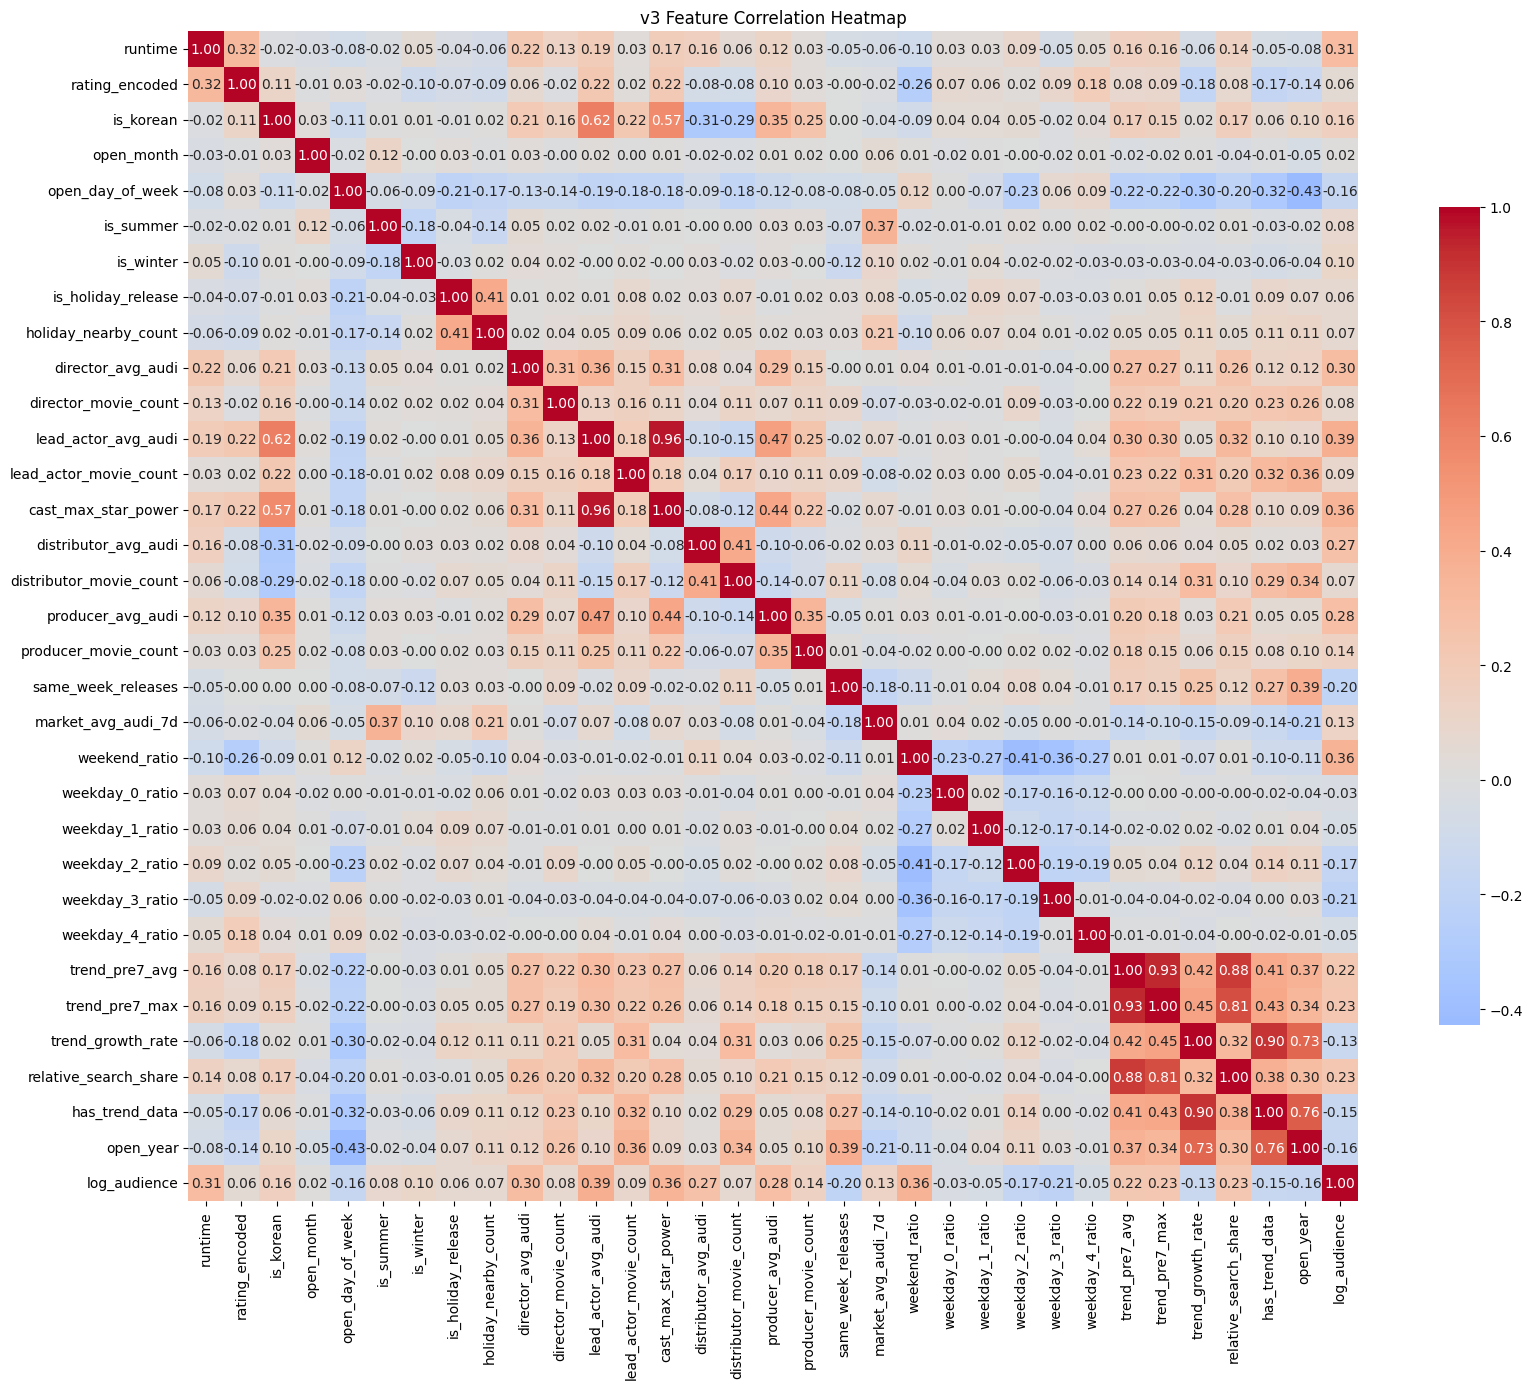

In [906]:
# =====================================================
# Feature Heatmap
# =====================================================

heatmap_cols = [
    col for col in numeric_cols
    if col != 'log_audience'
]

corr_matrix = df[
    heatmap_cols + ['log_audience']
].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'shrink': 0.7}
)

plt.title(f'{FEATURE_VERSION} Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. CatBoost Feature Importance 시각화

In [907]:
feature_names = X_train.columns

In [908]:
# =====================================================
# CatBoost Feature Importance
# =====================================================

feature_names = X.columns

cat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': cb_model.feature_importances_
})

cat_importance = (
    cat_importance
    .sort_values('importance', ascending=False)
)
cat_importance=cat_importance.reset_index()
print('=' * 60)
print(f'{FEATURE_VERSION} CatBoost Feature Importance TOP 20')
print('=' * 60)

display(cat_importance.head(20))

v3 CatBoost Feature Importance TOP 20


,index,feature,importance
0,21,weekend_ratio,14.513759
1,23,weekday_1_ratio,10.455913
2,25,weekday_3_ratio,7.997021
3,24,weekday_2_ratio,7.931989
4,22,weekday_0_ratio,7.485207
5,15,distributor_avg_audi,5.380386
6,20,market_avg_audi_7d,4.520008
7,12,lead_actor_avg_audi,3.892691
8,0,runtime,3.650394
9,10,director_avg_audi,3.377103


## 5. Feature Importance 시각화

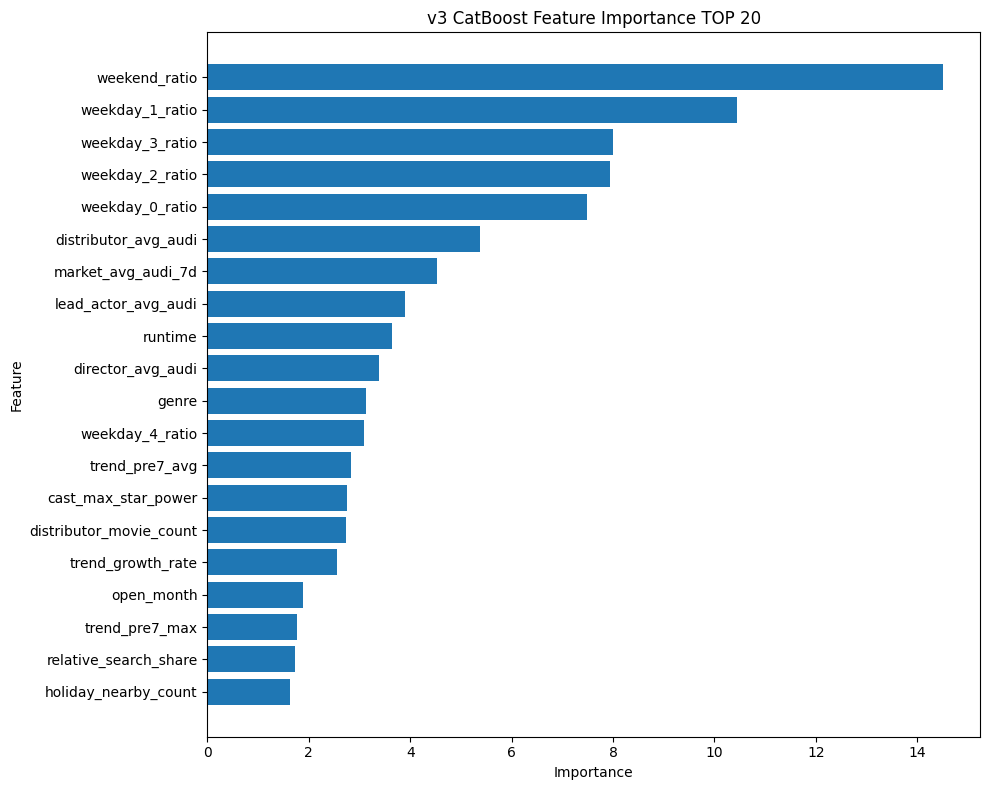

In [909]:
plt.figure(figsize=(10, 8))

plot_df = cat_importance.head(20).sort_values('importance')

plt.barh(
    plot_df['feature'],
    plot_df['importance']
)

plt.title(f'{FEATURE_VERSION} CatBoost Feature Importance TOP 20')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [910]:
# 모드별 파일명 자동 생성
period_tag = {
    "range"  : f"{PERIOD_START}_{PERIOD_END}",
    "exclude": f"ex{PERIOD_START}_{PERIOD_END}",
    "from"   : f"from{MIN_YEAR}",
}[PERIOD_MODE]

model_prefix = f"{FEATURE_VERSION}_{period_tag}"

with open(f"models/{model_prefix}_xgboost.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open(f"models/{model_prefix}_lightgbm.pkl", "wb") as f:
    pickle.dump(lgb_model, f)
with open(f"models/{model_prefix}_catboost.pkl", "wb") as f:
    pickle.dump(cb_model, f)

print(f"✅ 모델 저장 완료: models/{model_prefix}_*.pkl")

✅ 모델 저장 완료: models/v3_from2016_*.pkl
